# Push Notification Analysis

This notebook explores push notification data, including push timing, frequency, and basic distributions of push events.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import glob
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
# Get all push files
push_files = glob.glob("../../data/data1031/sleep_push_result_*.csv")

# Read and combine all push data
all_push_data_list = []
for file in push_files:
    df = pd.read_csv(file)
    df = df[['dt', 'member_id', 'trigger_tag', 'proposal_name', 'coupon', 'discount', 'policy_id']]
    all_push_data_list.append(df)

all_push_data = pd.concat(all_push_data_list, ignore_index=True)
all_push_data['dt'] = pd.to_datetime(all_push_data['dt'])
all_push_data.head()

,dt,member_id,trigger_tag,proposal_name,coupon,discount,policy_id
0,2021-02-24,86732,1,全场饮品抵用金40元券包,40.0,NaN,556f73c469a4cad3ba1da84d62035a2e
1,2020-08-23,613008,2,NaN,NaN,NaN,6e39b52e3b0700c2684b8eb0d2fd75e3
2,2021-06-14,613008,4,NaN,NaN,NaN,3349bc61a123584ee53025936922321b
3,2021-12-07,613008,1,4.2折饮品券,NaN,4.2,76b95b3734c97e72c17b20bcc63a4a75
4,2021-09-13,613008,4,NaN,NaN,NaN,e7944450abe0142c725b227605c17bfd


1. Unique members: 758325

2. Unique trigger_tags: 5
Trigger tag distribution:
trigger_tag
1    27965004
2    17517166
3     7936691
4     3182451
5      123209
Name: count, dtype: int64


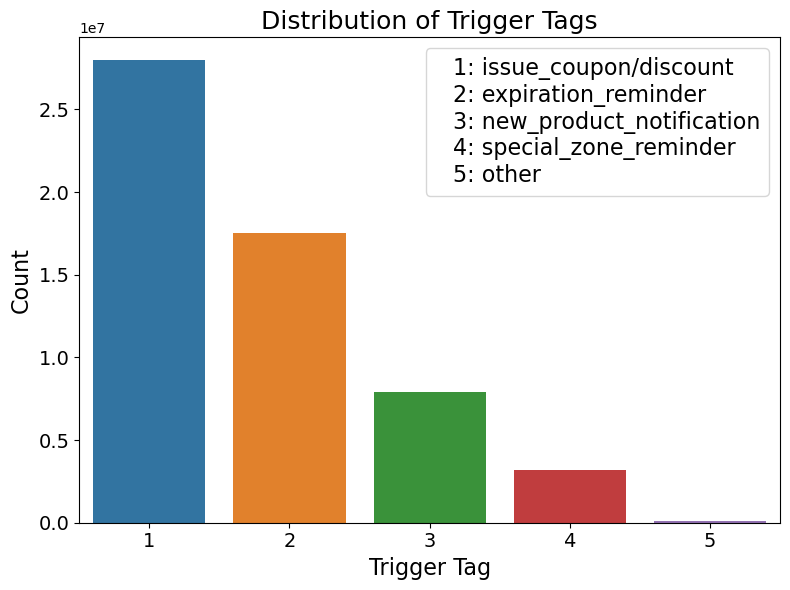

In [4]:
# 1. How many unique members?
unique_members = all_push_data['member_id'].nunique()
print(f"1. Unique members: {unique_members}")

# 2. How many unique trigger_tags, what is their portion, plot it
trigger_tag_counts = all_push_data['trigger_tag'].value_counts()
print(f"\n2. Unique trigger_tags: {len(trigger_tag_counts)}")
print("Trigger tag distribution:")
print(trigger_tag_counts)
# Create mapping dictionary
trigger_tag_names = {1: "issue_coupon/discount", 2: "expiration_reminder", 3: "new_product_notification", 
                     4: "special_zone_reminder", 5: "other"}

plt.figure(figsize=(8, 6))
sns.barplot(x=trigger_tag_counts.index, y=trigger_tag_counts.values)
plt.title('Distribution of Trigger Tags', fontsize=18)
plt.xlabel('Trigger Tag', fontsize=16)
plt.ylabel('Count', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Create legend text
legend_text = '\n'.join([f'{k}: {v}' for k, v in trigger_tag_names.items()])
plt.legend([legend_text], loc='upper right', fontsize=16, handlelength=0)

plt.tight_layout()
plt.savefig('trigger_tag_distribution.pdf', dpi=300)
plt.show();



3. Unique coupons: 28
Top 10 coupon distribution:
coupon
40.0    18724165
15.0      192933
61.0      143252
16.0      136494
9.9        45962
14.0       26376
13.0       13692
12.0       10364
17.0       10129
11.0        5982
Name: count, dtype: int64


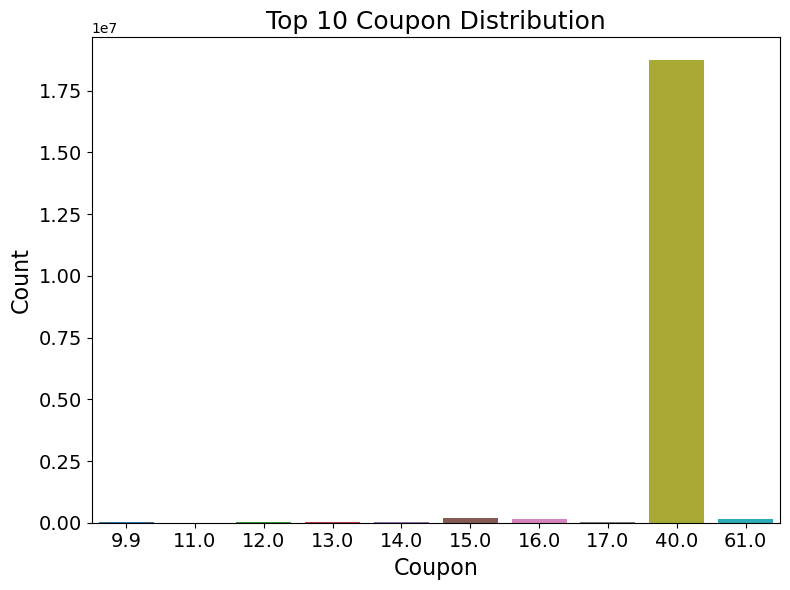

In [5]:

# 3. How many unique coupons, what is their portion, plot it
coupon_counts = all_push_data['coupon'].value_counts()
print(f"\n3. Unique coupons: {len(coupon_counts)}")
print("Top 10 coupon distribution:")
print(coupon_counts.head(10))

plt.figure(figsize=(8, 6))
sns.barplot(x=coupon_counts.head(10).index, y=coupon_counts.head(10).values)
plt.title('Top 10 Coupon Distribution', fontsize=18)
plt.xlabel('Coupon', fontsize=16)
plt.ylabel('Count', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.savefig('top_10_coupon_distribution.pdf', dpi=300)
plt.show();



4. Unique discounts: 16
Top 10 discount distribution:
discount
3.8    9187092
4.5     448935
4.2     413525
4.8     324049
5.0     286619
3.9     145820
4.1     100074
4.3      81938
4.6      38656
4.9       9644
Name: count, dtype: int64


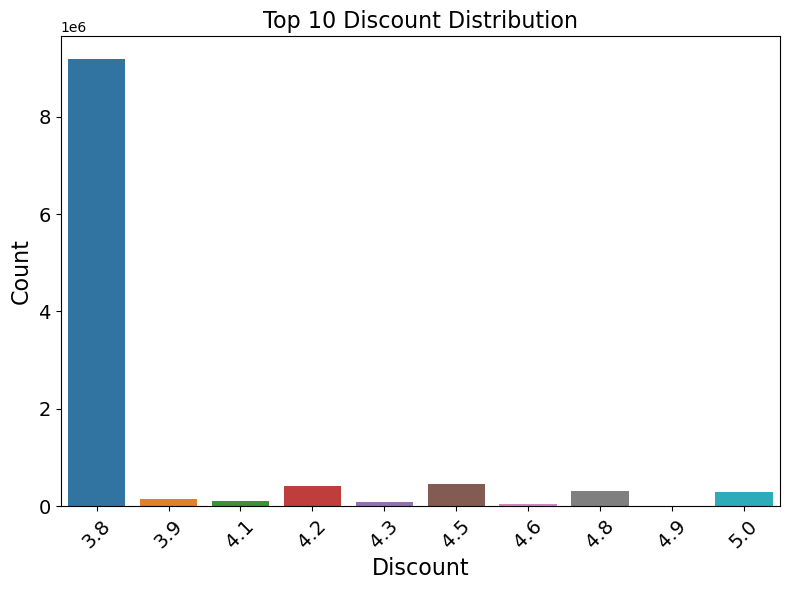

In [6]:

# 4. How many unique discounts, what is their portion, plot it
discount_counts = all_push_data['discount'].value_counts()
print(f"\n4. Unique discounts: {len(discount_counts)}")
print("Top 10 discount distribution:")
print(discount_counts.head(10))

plt.figure(figsize=(8, 6))
sns.barplot(x=discount_counts.head(10).index, y=discount_counts.head(10).values)
plt.title('Top 10 Discount Distribution', fontsize=16)
plt.xlabel('Discount', fontsize=16)
plt.ylabel('Count', fontsize=16)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.savefig('top_10_discount_distribution.pdf', dpi=300)
plt.show();

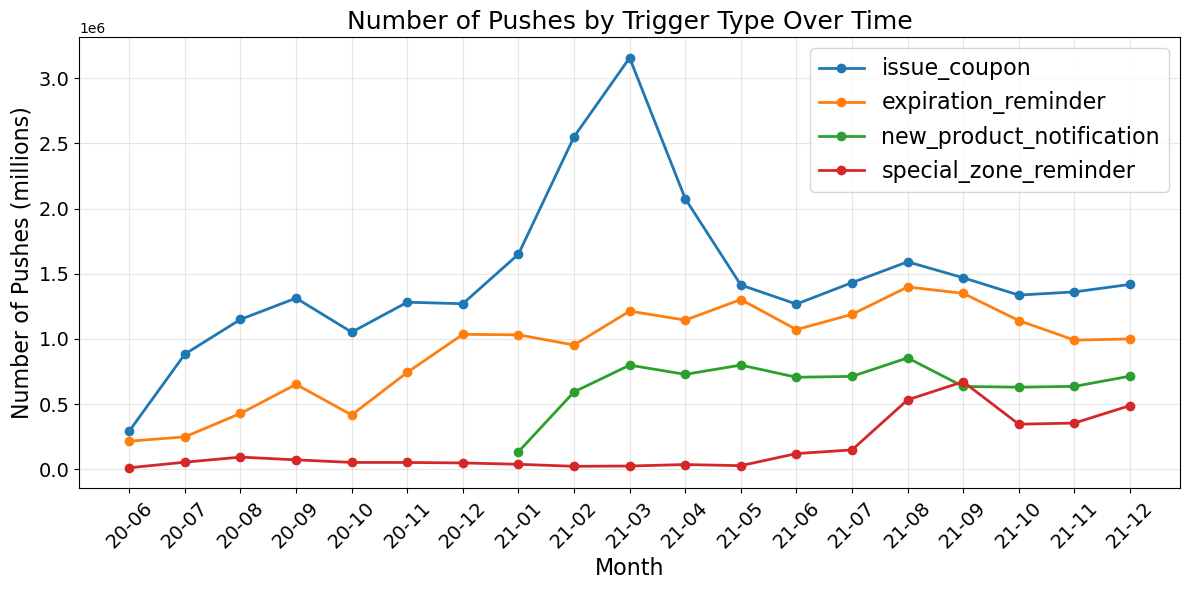

In [7]:
# Create mapping dictionary for legend
trigger_tag_names = {1: "issue_coupon", 2: "expiration_reminder", 3: "new_product_notification", 
                     4: "special_zone_reminder"}

# Colors for each trigger tag
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

plt.figure(figsize=(12, 6))

# Plot each trigger tag
for trigger in [1, 2, 3, 4]:
    trigger_data = all_push_data[all_push_data['trigger_tag'] == trigger].copy()
    trigger_data['month'] = trigger_data['dt'].dt.to_period('M')
    
    # Count pushes by month
    monthly_counts = trigger_data['month'].value_counts().sort_index()
    
    # Convert period to string in format YY-MM
    monthly_counts.index = monthly_counts.index.astype(str).str[2:]
    
    # Plot with different color
    plt.plot(monthly_counts.index, monthly_counts.values, marker='o', linewidth=2, 
             markersize=6, label=trigger_tag_names[trigger], color=colors[trigger-1])

plt.title('Number of Pushes by Trigger Type Over Time', fontsize=18)
plt.xlabel('Month', fontsize=16)
plt.ylabel('Number of Pushes (millions)', fontsize=16)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=16)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pushes_by_trigger_type_over_time.pdf', dpi=300)
plt.show();

/tmp/ipykernel_827232/240272298.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_users_2021_01['day'] = new_users_2021_01['first_purchase_date'].dt.day
/tmp/ipykernel_827232/240272298.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  push_2021_01['day'] = push_2021_01['dt'].dt.day


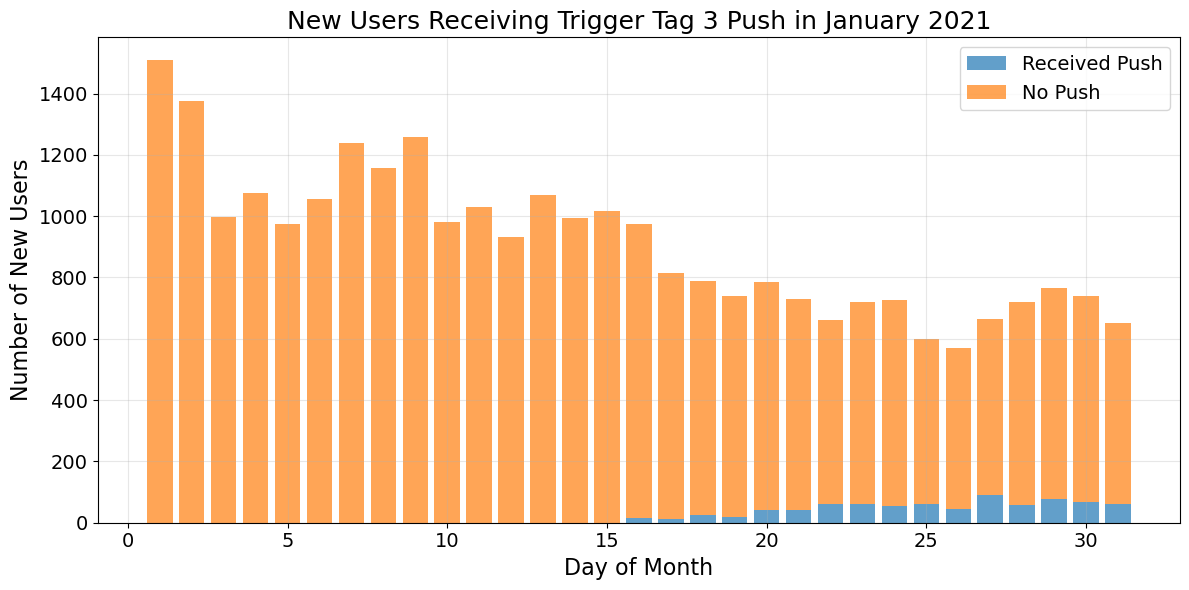

In [8]:
# combine order data
folder_path = '../../data/data1031'
file = 'order_result.csv'
file_path = os.path.join(folder_path, file)
columns = ["member_id", "dept_id", "create_hour", 
            "coffee_origin_money", "drink_not_coffee_origin_money", "food_origin_money",
            "coffee_commodity_num", "coffee_top_commodity_num",
            "not_coffee_commodity_num", "not_coffee_top_commodity_num",
            "food_commodity_num",
            "use_coupon_num",
            "coffee_discount", "disount_tag",
            "drink_not_coffee_discount"]
# only read the columns in the list
order_result = pd.read_csv(file_path, usecols=columns)
order_result['date'] = pd.to_datetime(order_result['create_hour'],
                                             format='%Y-%m-%d %H').dt.date
order_result['total_items'] = (order_result['coffee_commodity_num'] + 
                               order_result['not_coffee_commodity_num'])
order_result['total_top_items'] = (order_result['coffee_top_commodity_num'] + 
                                   order_result['not_coffee_top_commodity_num'])                                   
order_result['has_discount'] = (~order_result['coffee_discount'].isnull()) | (~order_result['drink_not_coffee_discount'].isnull())
order_result['drink_not_coffee_commodity_num'] = order_result['not_coffee_commodity_num'] - order_result['food_commodity_num']
# discard column 'create_hour'
order_result = order_result.drop(columns=['create_hour'])
order_result['date'] = pd.to_datetime(order_result['date'])


# Find all new users (first purchase across entire dataset)
first_purchases = order_result.groupby('member_id').agg({'date': 'min'}).reset_index()
first_purchases.columns = ['member_id', 'first_purchase_date']

# Filter new users who made first purchase in 2021-01
new_users_2021_01 = first_purchases[first_purchases['first_purchase_date'].dt.to_period('M') == '2021-01']

# Filter push data for 2021-01 and trigger_tag 3
push_2021_01 = all_push_data[
    (all_push_data['dt'].dt.to_period('M') == '2021-01') & 
    (all_push_data['trigger_tag'] == 3)
]

# Extract day from dates
new_users_2021_01['day'] = new_users_2021_01['first_purchase_date'].dt.day
push_2021_01['day'] = push_2021_01['dt'].dt.day

# Count new users by day
new_users_by_day = new_users_2021_01['day'].value_counts().sort_index()

# Count new users who received push by day
new_users_with_push = new_users_2021_01[
    new_users_2021_01['member_id'].isin(push_2021_01['member_id'])
]['day'].value_counts().sort_index()

# Create complete index for all days in January
all_days = range(1, 32)
new_users_by_day = new_users_by_day.reindex(all_days, fill_value=0)
new_users_with_push = new_users_with_push.reindex(all_days, fill_value=0)
# Calculate new users without push
new_users_without_push = new_users_by_day - new_users_with_push

# Plot
plt.figure(figsize=(12, 6))
plt.bar(new_users_with_push.index, new_users_with_push.values, label='Received Push', alpha=0.7)
plt.bar(new_users_without_push.index, new_users_without_push.values, 
        bottom=new_users_with_push.values, label='No Push', alpha=0.7)

plt.title('New Users Receiving Trigger Tag 3 Push in January 2021', fontsize=18)
plt.xlabel('Day of Month', fontsize=16)
plt.ylabel('Number of New Users', fontsize=16)
plt.legend(fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('new_users_receiving_trigger_tag_3_push_in_january_2021.pdf', dpi=300)
plt.show();

In [9]:
new_users_2021_01_pushed_later = new_users_2021_01[
    new_users_2021_01['member_id'].isin(push_2021_01['member_id'])
]
push_new_2021_01 = push_2021_01[push_2021_01['member_id'].isin(new_users_2021_01_pushed_later['member_id'])]

print('how many policies: ', push_new_2021_01['policy_id'].nunique())
print('how many times each member received push: ', push_new_2021_01['member_id'].value_counts().describe())


how many policies:  4
how many times each member received push:  count    792.000000
mean       1.299242
std        0.458216
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        2.000000
Name: count, dtype: float64


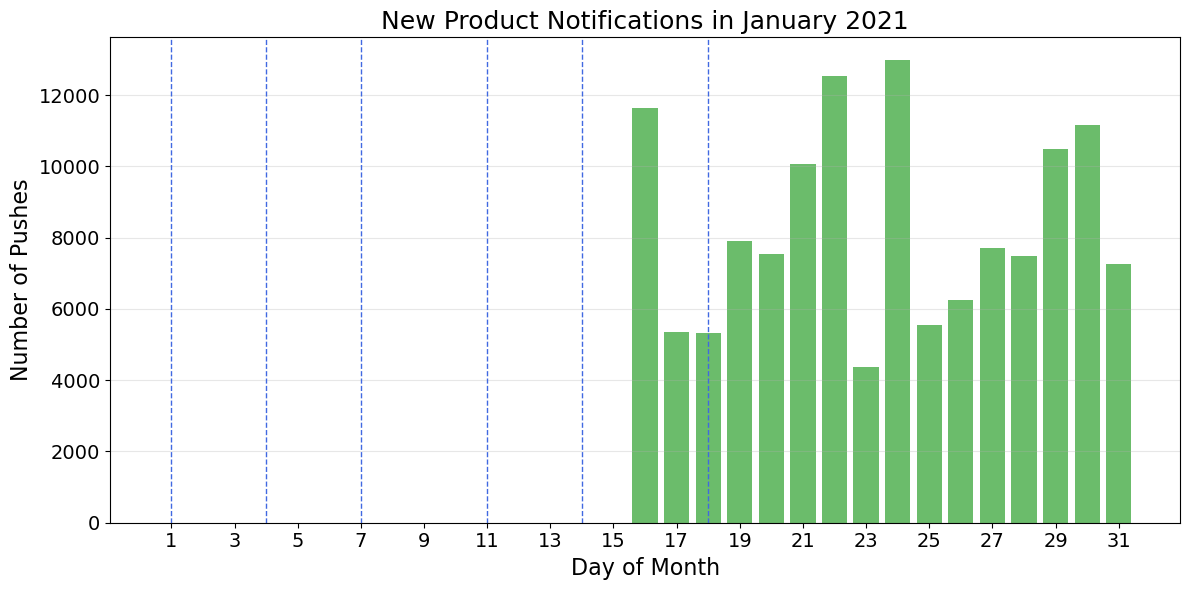

In [15]:
# Filter push data for 2021-01 and trigger_tag 3
push_tag3_2021_01 = all_push_data[
    (all_push_data['dt'].dt.to_period('M') == '2021-01') & 
    (all_push_data['trigger_tag'] == 3)
].copy()

# Extract day from dates
push_tag3_2021_01['day'] = push_tag3_2021_01['dt'].dt.day

# Count pushes by day
pushes_by_day = push_tag3_2021_01['day'].value_counts().sort_index()

# Create complete index for all days in January
all_days = range(1, 32)
pushes_by_day = pushes_by_day.reindex(all_days, fill_value=0)

# Plot
plt.figure(figsize=(12, 6))

# add some vertical lines: 1, 4, 7, 11, 14, 18
plt.axvline(x=1, color='RoyalBlue', linestyle='--', linewidth=1)
plt.axvline(x=4, color='RoyalBlue', linestyle='--', linewidth=1)
plt.axvline(x=7, color='RoyalBlue', linestyle='--', linewidth=1)
plt.axvline(x=11, color='RoyalBlue', linestyle='--', linewidth=1)
plt.axvline(x=14, color='RoyalBlue', linestyle='--', linewidth=1)
plt.axvline(x=18, color='RoyalBlue', linestyle='--', linewidth=1)

plt.bar(pushes_by_day.index, pushes_by_day.values, alpha=0.7, color='#2ca02c')
plt.title('New Product Notifications in January 2021', fontsize=18)
plt.xlabel('Day of Month', fontsize=16)
plt.ylabel('Number of Pushes', fontsize=16)
plt.xticks(range(1, 32, 2), fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('pushes_trigger_tag_3_january_2021.pdf', dpi=300)
plt.show();
